In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv('IRIS.csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head(10)

Dataset loaded successfully!
Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [3]:
print("=== Dataset Information ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

=== Missing Values ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

=== Basic Statistics ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


=== Species Distribution ===
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


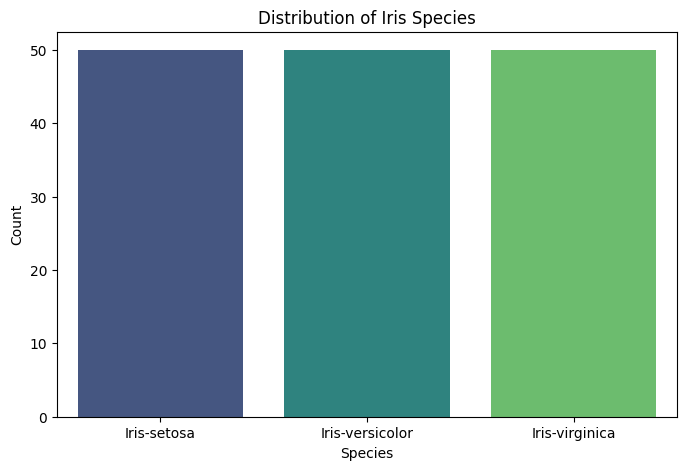

In [4]:
print("=== Species Distribution ===")
print(df['species'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x='species', data=df, palette='viridis')
plt.title('Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

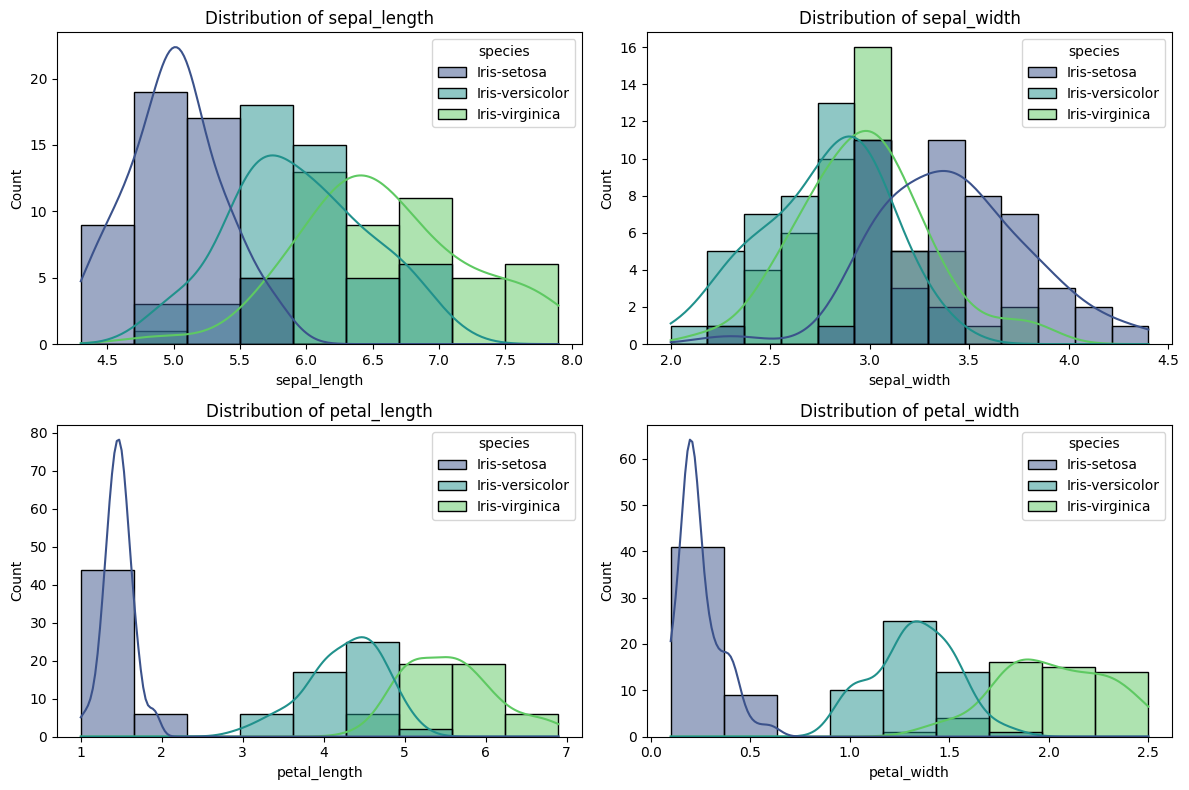

In [5]:
plt.figure(figsize=(12, 8))
for i, feature in enumerate(['sepal_length', 'sepal_width', 'petal_length', 'petal_width']):
    plt.subplot(2, 2, i+1)
    sns.histplot(data=df, x=feature, hue='species', kde=True, palette='viridis')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

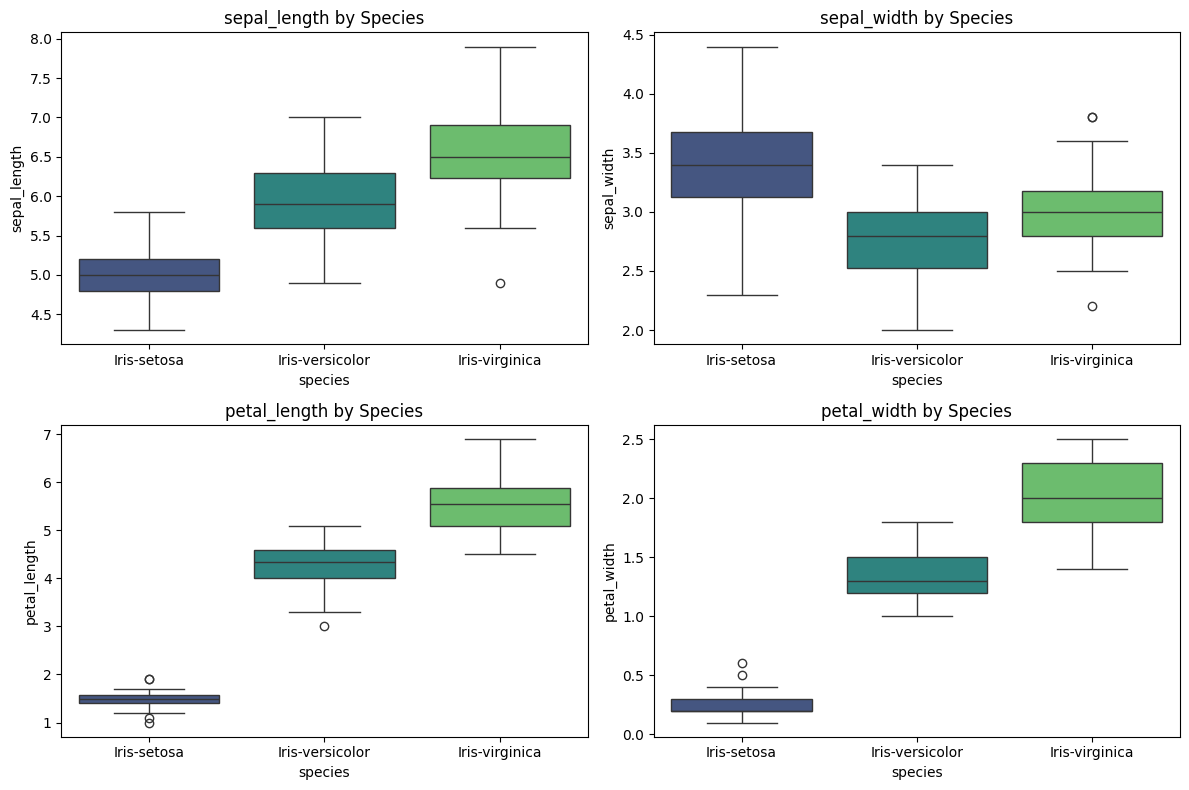

In [6]:
plt.figure(figsize=(12, 8))
for i, feature in enumerate(['sepal_length', 'sepal_width', 'petal_length', 'petal_width']):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=df, x='species', y=feature, palette='viridis')
    plt.title(f'{feature} by Species')
plt.tight_layout()
plt.show()

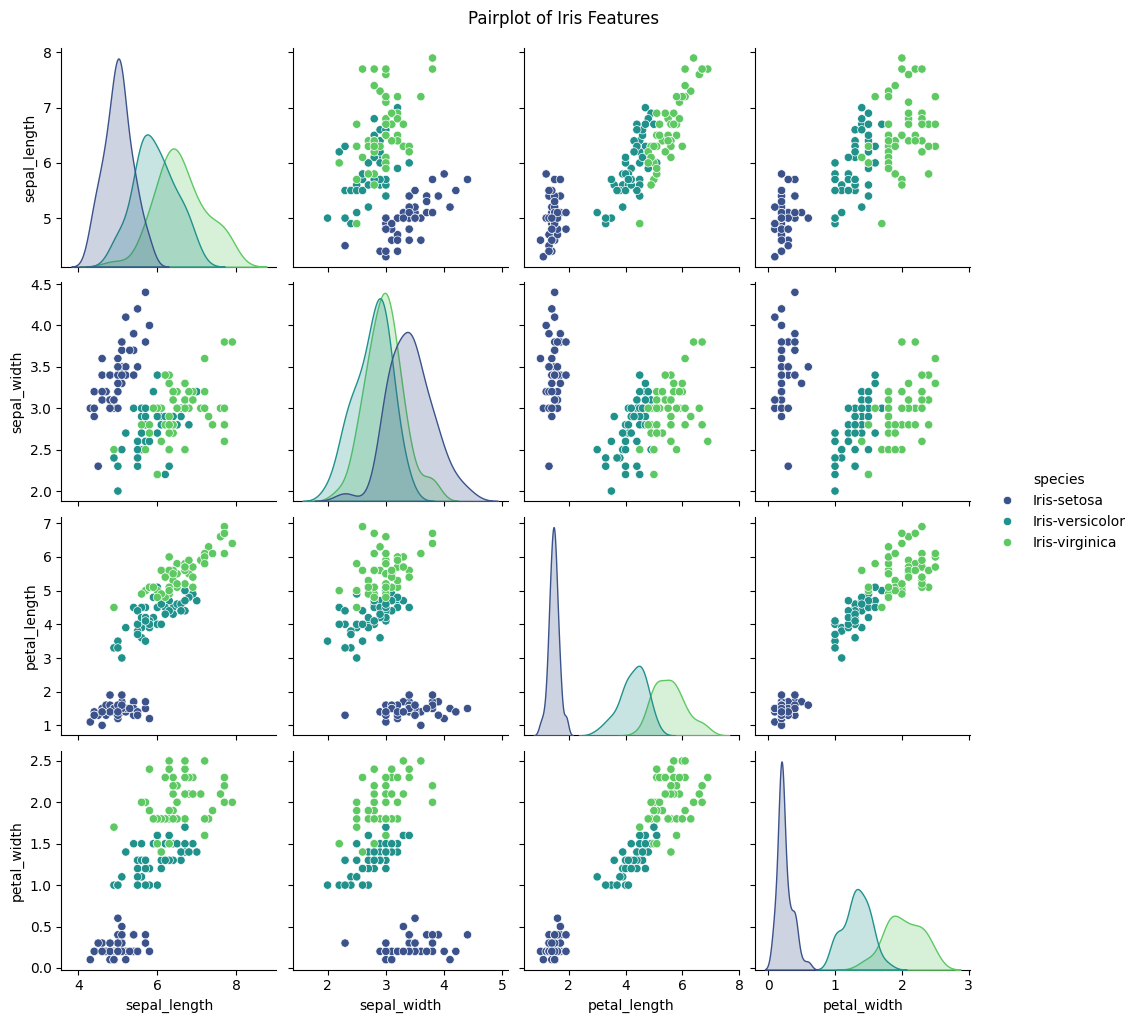

In [7]:
sns.pairplot(df, hue='species', palette='viridis')
plt.suptitle('Pairplot of Iris Features', y=1.02)
plt.show()

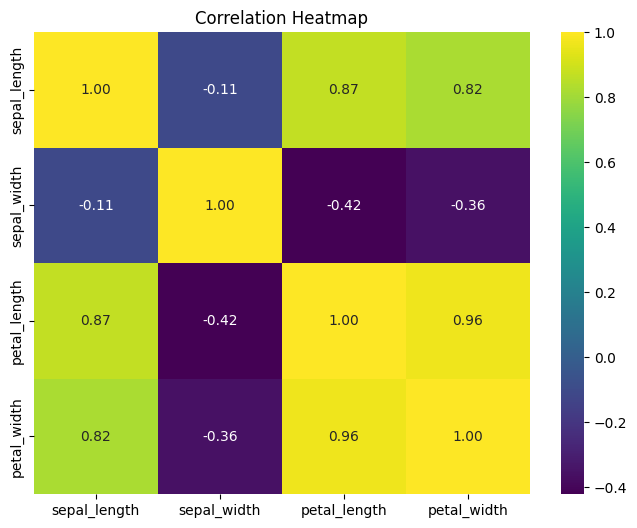

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop('species', axis=1).corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [9]:
X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total samples: {len(df)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"\nFeatures: {list(X.columns)}")
print(f"Target: species")
print(f"\nTraining data sample:")
X_train.head()

Total samples: 150
Training samples: 120
Testing samples: 30

Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Target: species

Training data sample:


,sepal_length,sepal_width,petal_length,petal_width
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2


In [10]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print("=== Logistic Regression ===")
print(f"Accuracy: {lr_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

=== Logistic Regression ===
Accuracy: 100.00%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [11]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("=== Decision Tree ===")
print(f"Accuracy: {dt_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

=== Decision Tree ===
Accuracy: 100.00%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [12]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print("=== K-Nearest Neighbors ===")
print(f"Accuracy: {knn_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

=== K-Nearest Neighbors ===
Accuracy: 100.00%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [13]:
svm = SVC(random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print("=== Support Vector Machine ===")
print(f"Accuracy: {svm_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

=== Support Vector Machine ===
Accuracy: 100.00%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [14]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("=== Random Forest ===")
print(f"Accuracy: {rf_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

=== Random Forest ===
Accuracy: 100.00%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



=== Model Comparison ===
              Model  Accuracy
Logistic Regression     100.0
      Decision Tree     100.0
                KNN     100.0
                SVM     100.0
      Random Forest     100.0

Best Model: Logistic Regression
Best Accuracy: 100.00%


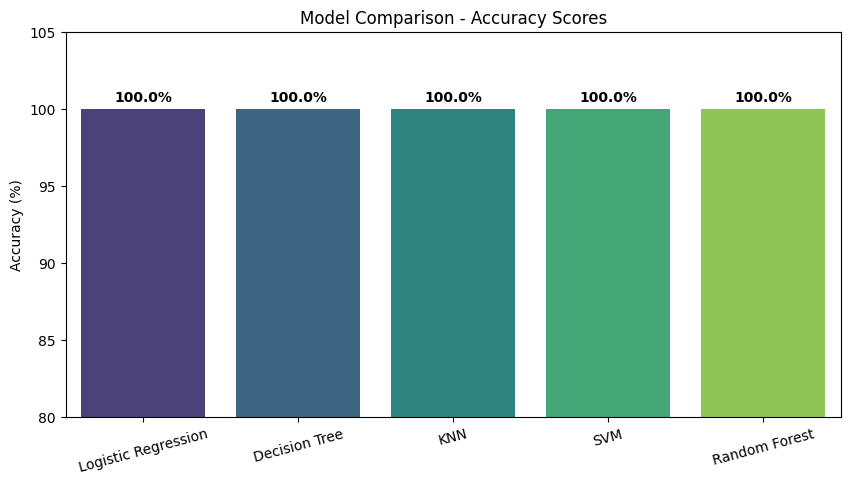

In [15]:
models = ['Logistic Regression', 'Decision Tree', 'KNN', 'SVM', 'Random Forest']
accuracies = [lr_acc, dt_acc, knn_acc, svm_acc, rf_acc]

comparison_df = pd.DataFrame({'Model': models, 'Accuracy': [round(a*100, 2) for a in accuracies]})
print("=== Model Comparison ===")
print(comparison_df.to_string(index=False))
print(f"\nBest Model: {models[accuracies.index(max(accuracies))]}")
print(f"Best Accuracy: {max(accuracies)*100:.2f}%")

plt.figure(figsize=(10, 5))
sns.barplot(x=models, y=[a*100 for a in accuracies], palette='viridis')
plt.title('Model Comparison - Accuracy Scores')
plt.ylabel('Accuracy (%)')
plt.ylim(80, 105)
for i, v in enumerate(accuracies):
    plt.text(i, v*100 + 0.5, f'{v*100:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=15)
plt.show()

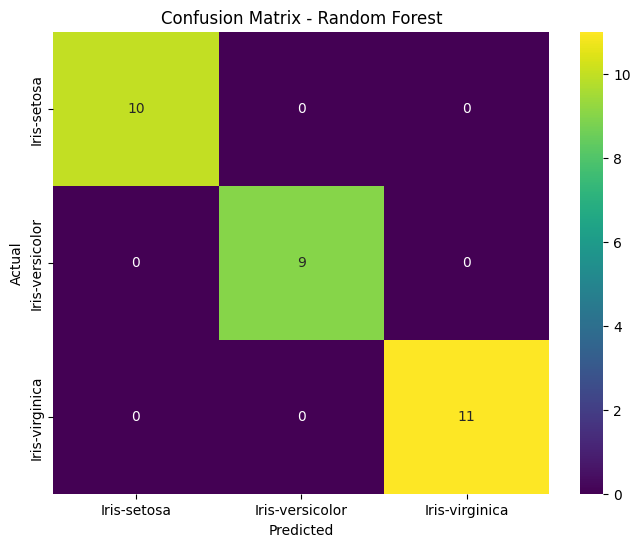

In [16]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=df['species'].unique(),
            yticklabels=df['species'].unique())
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

=== Feature Importance ===
     Feature  Importance Score
petal_length          0.439994
 petal_width          0.421522
sepal_length          0.108098
 sepal_width          0.030387


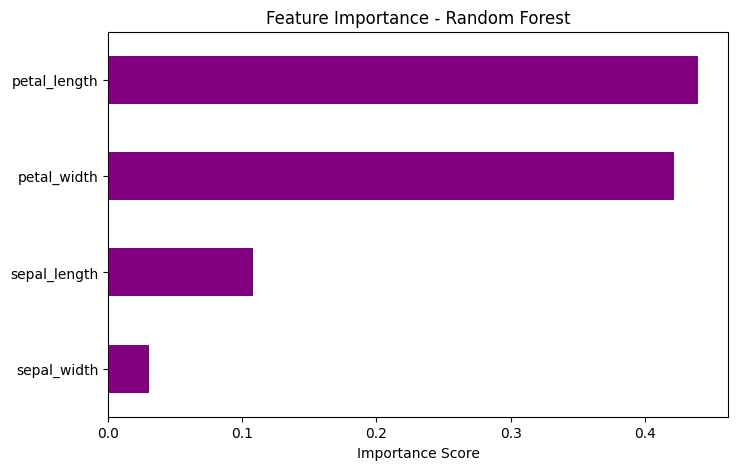

In [17]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance_df = importance.sort_values(ascending=False).reset_index()
importance_df.columns = ['Feature', 'Importance Score']

print("=== Feature Importance ===")
print(importance_df.to_string(index=False))

importance.sort_values().plot(kind='barh', color='purple', figsize=(8, 5))
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.show()

In [18]:
new_flower = pd.DataFrame({
    'sepal_length': [5.1],
    'sepal_width': [3.5],
    'petal_length': [1.4],
    'petal_width': [0.2]
})

prediction = rf.predict(new_flower)

print("=== New Flower Prediction ===")
print(f"Sepal Length: 5.1 cm")
print(f"Sepal Width: 3.5 cm")
print(f"Petal Length: 1.4 cm")
print(f"Petal Width: 0.2 cm")
print(f"\nPredicted Species: {prediction[0]}")

=== New Flower Prediction ===
Sepal Length: 5.1 cm
Sepal Width: 3.5 cm
Petal Length: 1.4 cm
Petal Width: 0.2 cm

Predicted Species: Iris-setosa
